In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data\Telco-Customer-Churn.csv")

pd.set_option('display.max_columns', None)

df.shape

(7043, 21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

## I am Changing boolean columns, Assigning 1 to 'Yes', 0 to 'No'

In [6]:
df['IsMale'] = (df['gender'] == 'Male').astype(int)
# Convert Churn strings to 1/0 integers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.insert(df.columns.get_loc('gender'), 'IsMale', df.pop('IsMale'))
df.drop(columns=['gender'], inplace=True)

In [7]:
cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [8]:
numeric_cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
print(df.isna().sum())

customerID           0
IsMale               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## Fill Null values with 0

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## Churn Distibution plot

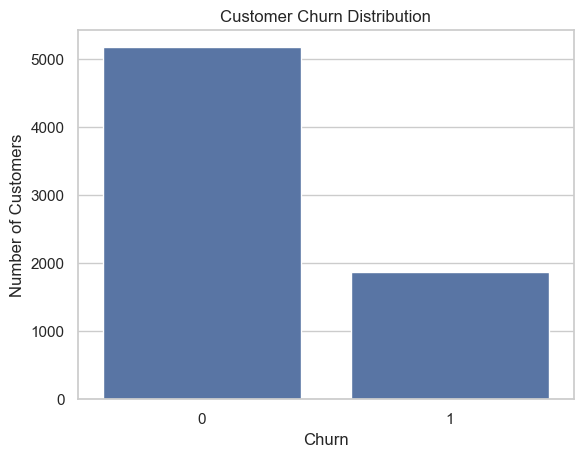

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [12]:
sns.set_theme(style="whitegrid")

sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

print(df["Churn"].value_counts(normalize=True) * 100)

## Churn Distiburion by Categorical Columns Plots

In [13]:
def plot_churn_rate(data, column, ax):
    churn_rate_df = data.groupby(column)['Churn'].mean()*100
    churn_rate_df.plot(
        kind="bar",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel(None)
    ax.set_ylabel("Churn Rate (%)")
    rotation = 45 if column == "PaymentMethod" else 0
    ax.tick_params(axis="x", rotation=rotation)
    ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
    ax.set_ylim(0, churn_rate_df.max() * 1.15)

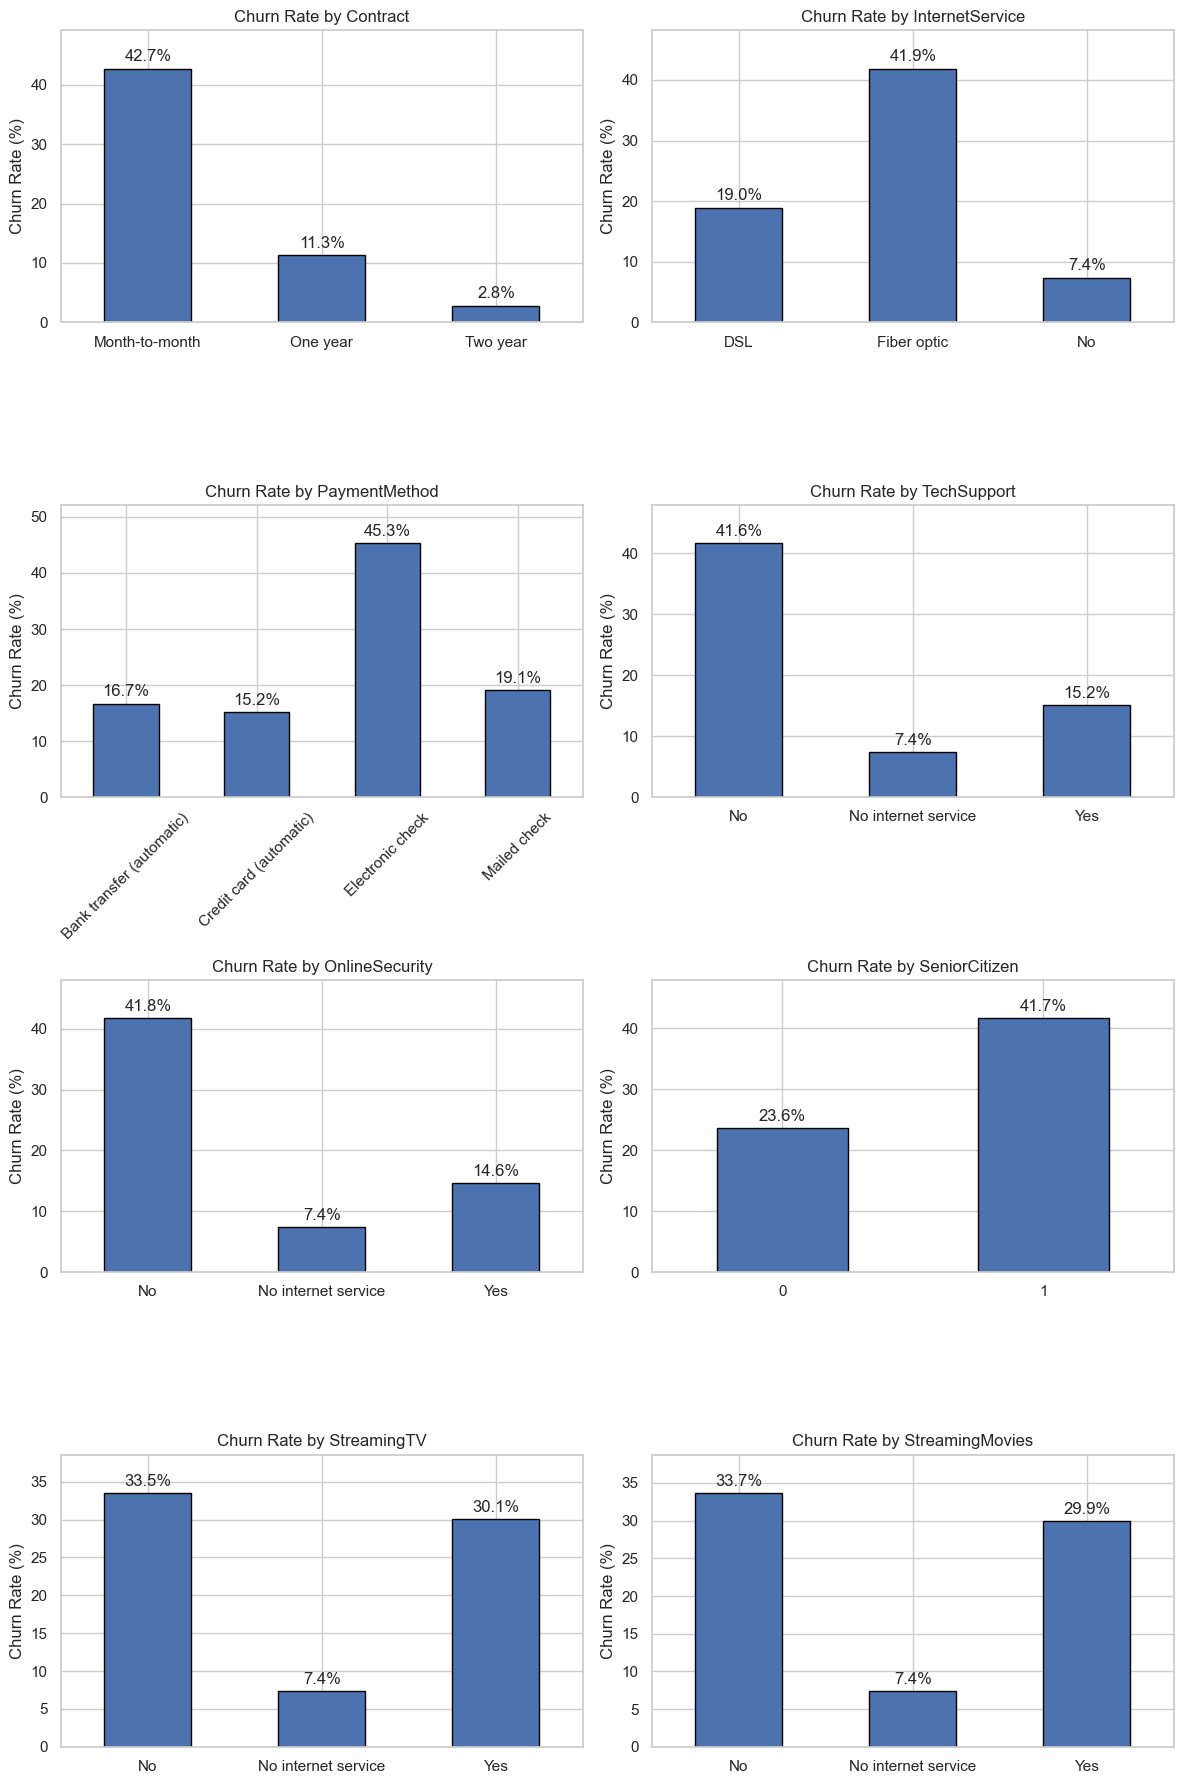

In [14]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 18)
)

columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "SeniorCitizen",
    "StreamingTV",
    "StreamingMovies"
    
]

# MultipleLines          3
# InternetService        3
# OnlineSecurity         3
# OnlineBackup           3
# DeviceProtection       3
# TechSupport            3
# StreamingTV            3
# StreamingMovies        3
# Contract               3
# PaymentMethod          4

for ax, column in zip(axes.flat, columns):
    plot_churn_rate(df, column, ax)

plt.tight_layout()
plt.show()

## Churn and Numerical Data Insights

<Axes: xlabel='Churn', ylabel='tenure'>

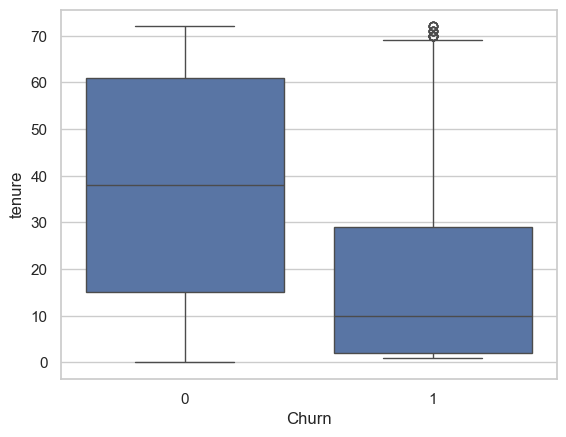

In [15]:
numeric_cols = ['TotalCharges', 'MonthlyCharges', 'tenure']
sns.boxplot(data = df, x = 'Churn', y = 'tenure')

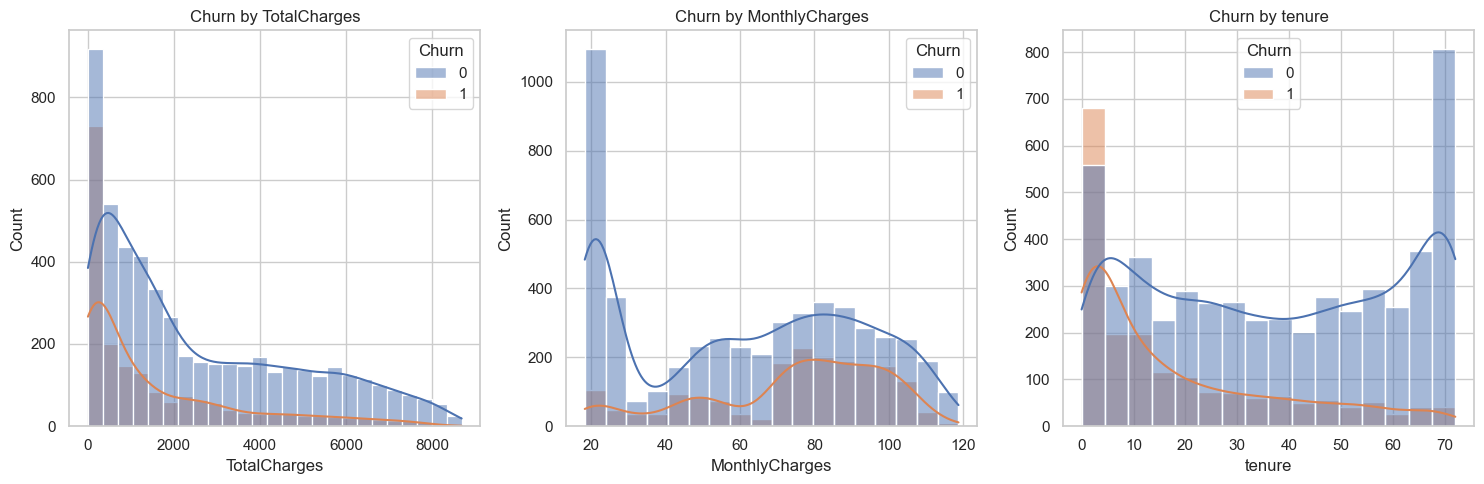

In [16]:
def plot_numericals(data, column, legend, ax):
    sns.histplot(
        data = data,
        x = column,
        hue = legend,
        kde = True,
        ax=ax
    )
    ax.set_title(f'Churn by {column}')
    plt.tight_layout()

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15,5))

numeric_cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

for ax, column in zip(axes, numeric_cols):
    plot_numericals(df,column,'Churn',ax)

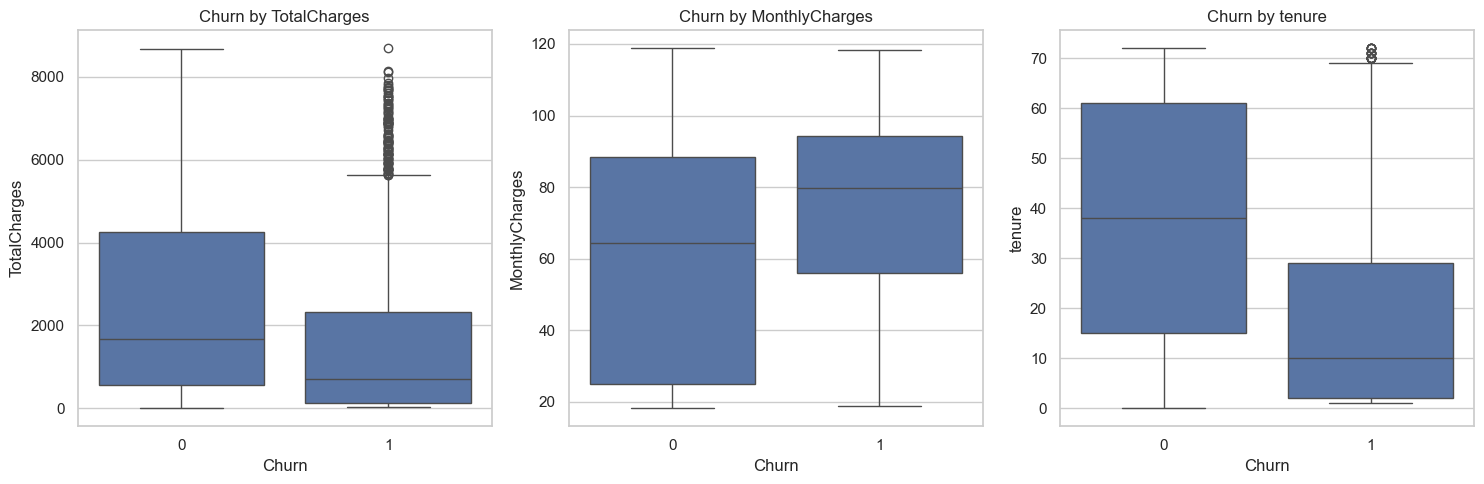

In [17]:
def plot_numericals(data, column, ax):
    sns.boxplot(
        data = data,
        x = 'Churn',
        y = column,
        ax=ax
    )
    ax.set_title(f'Churn by {column}')
    plt.tight_layout()

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15,5))

numeric_cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

for ax, column in zip(axes, numeric_cols):
    plot_numericals(df,column,ax)

## Correlation Heatmap

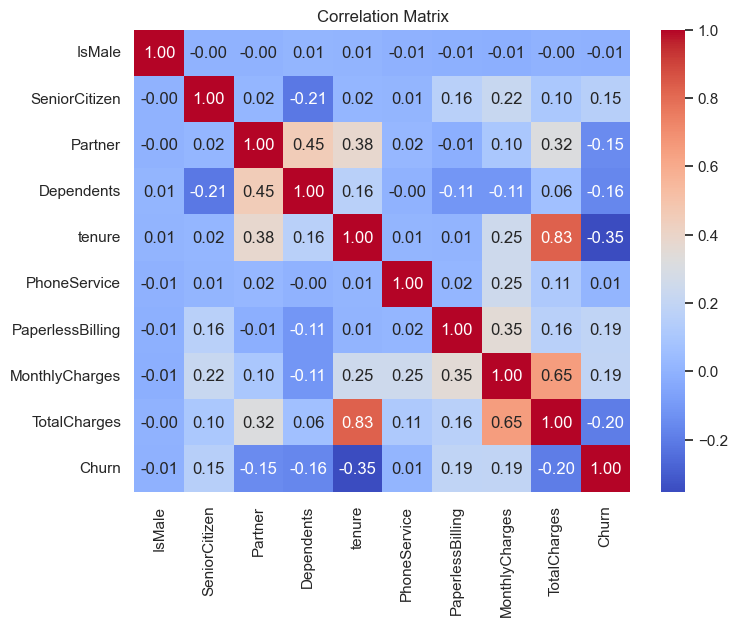

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='tenure', ylabel='TotalCharges'>

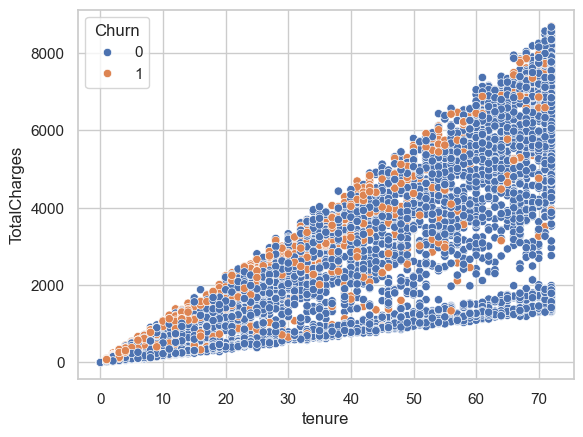

In [19]:
sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Churn"
)

## Adding custom Features. TotalServices and TenureGroup

In [20]:
df['TotalServices'] = (
    (df['PhoneService'] == 'Yes').astype(int)
    + (df['MultipleLines'].isin(['Yes'])).astype(int)
    + (df['InternetService'] != 'No').astype(int)
    + (df['OnlineSecurity'] == 'Yes').astype(int)
    + (df['OnlineBackup'] == 'Yes').astype(int)
    + (df['DeviceProtection'] == 'Yes').astype(int)
    + (df['TechSupport'] == 'Yes').astype(int)
    + (df['StreamingTV'] == 'Yes').astype(int)
    + (df['StreamingMovies'] == 'Yes').astype(int)
)

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 60, 72],
    labels=["0–6", "7–12", "13–24", "25–48", "49–60", "61–72"]
)

## Train/Test split

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42, stratify=y
)